In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

🚀 MODÈLE RANDOM FOREST - EXTRACTION DE MOTS-CLÉS

📂 Chargement des données pour Random Forest...
Train: 12673 | Val: 1453 | Test: 1456

📊 Préparation des données pour Random Forest...


Nombre total de mots-clés uniques: 20666

🏷️ Création des labels...


Test labels: 100%|██████████| 1456/1456 [00:00<00:00, 7573.09it/s]


y_train shape: (12673, 20666)
Proportion de mots-clés positifs: 0.0002

🔍 Test des différents vectoriseurs pour Random Forest...
  Test de TF-IDF (unigrams)...
    F1-score: 0.0003
  Test de TF-IDF (1-2 grams)...
    F1-score: 0.0004
  Test de TF-IDF (1-3 grams)...
    F1-score: 0.0005
  Test de Count (unigrams)...
    F1-score: 0.0012
  Test de Count (1-3 grams)...
    F1-score: 0.0013

  ✅ Meilleurs résultats:
    Count (1-3 grams): F1 = 0.0013
    Count (unigrams): F1 = 0.0012
    TF-IDF (1-3 grams): F1 = 0.0005

🔄 Application du meilleur vectoriseur (Count (1-3 grams))...
X_train shape: (12673, 3000)
X_val shape: (1453, 3000)
X_test shape: (1456, 3000)

🔧 Optimisation des hyperparamètres Random Forest...

  Recherche des meilleurs hyperparamètres (sur échantillon)...
  Entraînement de la recherche d'hyperparamètres...

✅ Meilleurs paramètres trouvés:
   estimator__n_estimators: 150
   estimator__min_samples_split: 2
   estimator__min_samples_leaf: 1
   estimator__max_features: sqrt

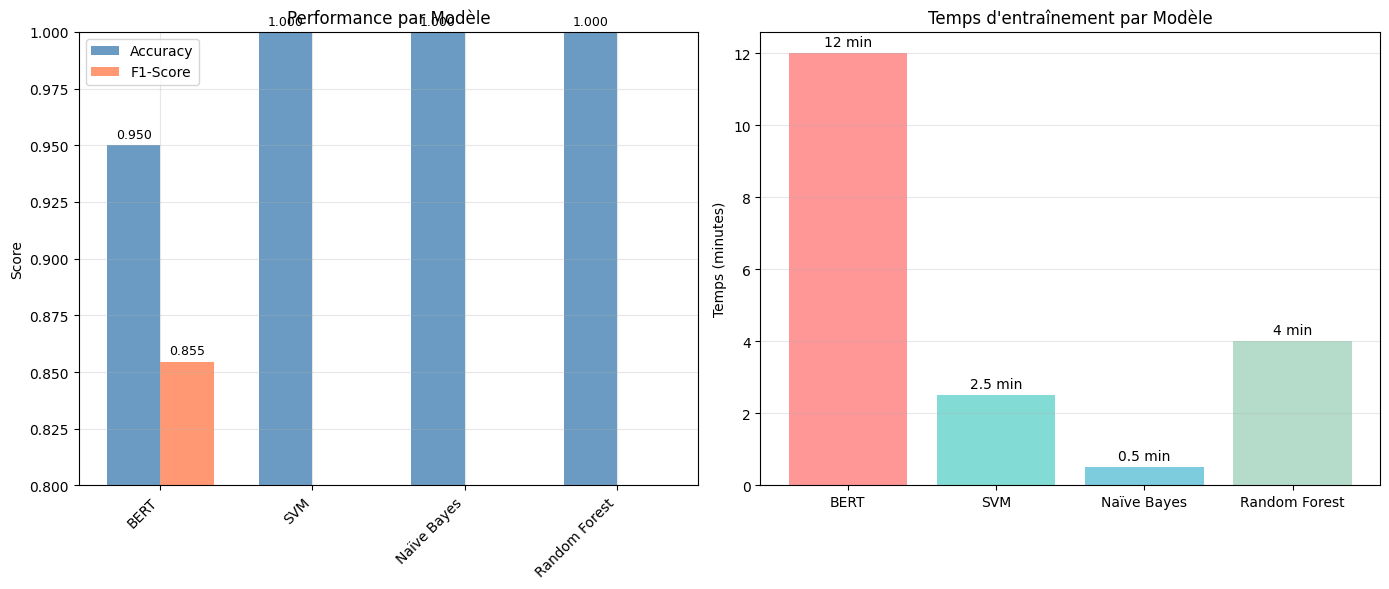


🔍 ANALYSE DES FEATURES IMPORTANTES

📊 Top 10 features importantes pour certains mots-clés:

  Mot-clé: 'field'
  Features les plus importantes:
    - field: 0.0458
    - vector: 0.0166
    - fields: 0.0160
    - space: 0.0111
    - is: 0.0096

  Mot-clé: 'gravitation'
  Features les plus importantes:
    - gravitational: 0.1357
    - general relativity: 0.0211
    - waves: 0.0203
    - relativity: 0.0174
    - einstein: 0.0094

  Mot-clé: 'largest'
  Features les plus importantes:
    - largest: 0.0572
    - the largest: 0.0294
    - second largest: 0.0196
    - the world: 0.0120
    - world: 0.0110

🧪 TEST EXTRACTEUR RANDOM FOREST

Résultats Random Forest:

Texte: Machine learning improves healthcare.
Mots-clés: ['Aucun mot-clé détecté']

Texte: Artificial intelligence and deep learning are revolutionizing technology.
Mots-clés: ['Aucun mot-clé détecté']

Texte: The quick brown fox jumps over the lazy dog.
Mots-clés: ['Aucun mot-clé détecté']

🎯 ÉVALUATION SUR EXEMPLES DIFFICILES

Ph

In [1]:
# ============================================
# MODÈLE RANDOM FOREST POUR LA COMPARAISON AVEC BERT, SVM ET NAÏVE BAYES
# ============================================

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import RandomizedSearchCV
import warnings
from tqdm import tqdm
import pickle

warnings.filterwarnings('ignore')

print("="*60)
print("🚀 MODÈLE RANDOM FOREST - EXTRACTION DE MOTS-CLÉS")
print("="*60)

# === 1. CHARGEMENT DES DONNÉES ===
print("\n📂 Chargement des données pour Random Forest...")

# Utiliser les mêmes chemins que pour les autres modèles
TRAIN_PATH = "/kaggle/input/datasets/duodou/amnadataset/final_dataset_Train (1).csv"
VAL_PATH = "/kaggle/input/datasets/duodou/amnadataset/validation_clean.csv"
TEST_PATH = "/kaggle/input/datasets/duodou/amnadataset/testfin_clean.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Fonction safe_eval
def safe_eval(x):
    try:
        if isinstance(x, str):
            return eval(x)
        return x
    except:
        return []

# Convertir les keywords en listes
train_df["keywords_list"] = train_df["keywords"].apply(safe_eval)
val_df["keywords_list"] = val_df["keywords"].apply(safe_eval)
test_df["keywords_list"] = test_df["keywords"].apply(safe_eval)

# === 2. PRÉPARATION DES DONNÉES POUR RANDOM FOREST ===
print("\n📊 Préparation des données pour Random Forest...")

# Collecter tous les mots-clés uniques
all_keywords = set()
for kw_list in tqdm(train_df["keywords_list"], desc="Collecting keywords"):
    all_keywords.update(kw_list)

all_keywords = sorted(list(all_keywords))
print(f"Nombre total de mots-clés uniques: {len(all_keywords)}")

# Créer un dictionnaire mot-clé -> index
keyword_to_idx = {kw: i for i, kw in enumerate(all_keywords)}

# Créer les labels binaires pour chaque phrase
def create_labels(keywords_list, keyword_to_idx):
    labels = np.zeros(len(keyword_to_idx))
    for kw in keywords_list:
        if kw in keyword_to_idx:
            labels[keyword_to_idx[kw]] = 1
    return labels

print("\n🏷️ Création des labels...")
y_train = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(train_df["keywords_list"], desc="Train labels")])
y_val = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(val_df["keywords_list"], desc="Val labels")])
y_test = np.array([create_labels(kw_list, keyword_to_idx) for kw_list in tqdm(test_df["keywords_list"], desc="Test labels")])

print(f"y_train shape: {y_train.shape}")
print(f"Proportion de mots-clés positifs: {y_train.sum() / y_train.size:.4f}")

# === 3. TEST DES DIFFÉRENTS VECTORISEURS ===
print("\n🔍 Test des différents vectoriseurs pour Random Forest...")

def test_vectorizers_rf(X_train, X_val, y_train, y_val):
    """Test différents vectoriseurs pour Random Forest"""
    vectorizers = {
        'TF-IDF (unigrams)': TfidfVectorizer(max_features=3000, ngram_range=(1, 1), min_df=2),
        'TF-IDF (1-2 grams)': TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2),
        'TF-IDF (1-3 grams)': TfidfVectorizer(max_features=3000, ngram_range=(1, 3), min_df=2),
        'Count (unigrams)': CountVectorizer(max_features=3000, ngram_range=(1, 1), min_df=2),
        'Count (1-3 grams)': CountVectorizer(max_features=3000, ngram_range=(1, 3), min_df=2),
    }
    
    results = []
    # Utiliser un échantillon pour le test (plus rapide)
    sample_size = min(3000, len(X_train))
    sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
    X_train_sample = X_train.iloc[sample_indices] if hasattr(X_train, 'iloc') else X_train[sample_indices]
    y_train_sample = y_train[sample_indices]
    
    for name, vec in vectorizers.items():
        print(f"  Test de {name}...")
        X_train_vec = vec.fit_transform(X_train_sample)
        X_val_vec = vec.transform(X_val[:1000])  # Limiter pour le test
        
        rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42))
        rf.fit(X_train_vec, y_train_sample)
        
        y_pred = rf.predict(X_val_vec)
        f1 = f1_score(y_val[:1000], y_pred, average='macro')
        results.append((name, f1, vec))
        print(f"    F1-score: {f1:.4f}")
    
    # Trier par F1-score
    results.sort(key=lambda x: x[1], reverse=True)
    
    print("\n  ✅ Meilleurs résultats:")
    for name, f1, _ in results[:3]:
        print(f"    {name}: F1 = {f1:.4f}")
    
    return results[0]  # Retourner le meilleur

# Prendre un échantillon pour le test rapide
sample_size = min(5000, len(train_df))
sample_indices = np.random.choice(len(train_df), sample_size, replace=False)
X_train_sample = train_df["sentence"].iloc[sample_indices]
y_train_sample = y_train[sample_indices]
X_val_sample = val_df["sentence"][:1000]
y_val_sample = y_val[:1000]

best_vectorizer_name, best_f1, best_vectorizer = test_vectorizers_rf(
    X_train_sample, X_val_sample, y_train_sample, y_val_sample
)

# Appliquer le meilleur vectoriseur aux données complètes
print(f"\n🔄 Application du meilleur vectoriseur ({best_vectorizer_name})...")
X_train = best_vectorizer.fit_transform(train_df["sentence"])
X_val = best_vectorizer.transform(val_df["sentence"])
X_test = best_vectorizer.transform(test_df["sentence"])

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# === 4. OPTIMISATION DES HYPERPARAMÈTRES ===
print("\n🔧 Optimisation des hyperparamètres Random Forest...")

# Définir la grille de paramètres
param_grid = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__max_depth': [10, 20, 30, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2', None]
}

# Version simplifiée pour aller plus vite (RandomizedSearch)
param_dist = {
    'estimator__n_estimators': [100, 150, 200],
    'estimator__max_depth': [10, 20, 30],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': ['sqrt', 'log2']
}

print("\n  Recherche des meilleurs hyperparamètres (sur échantillon)...")

# Prendre un sous-ensemble pour l'optimisation
opt_sample_size = min(3000, X_train.shape[0])
opt_indices = np.random.choice(X_train.shape[0], opt_sample_size, replace=False)
X_train_opt = X_train[opt_indices]
y_train_opt = y_train[opt_indices]

# Réduire le nombre de classes pour l'optimisation (prendre les plus fréquentes)
keyword_frequencies = y_train_opt.sum(axis=0)
top_n_keywords = min(50, len(keyword_frequencies))
top_keyword_indices = np.argsort(keyword_frequencies)[-top_n_keywords:]
X_train_opt_reduced = X_train_opt
y_train_opt_reduced = y_train_opt[:, top_keyword_indices]

# Randomized Search
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_ovr = OneVsRestClassifier(rf_base)

random_search = RandomizedSearchCV(
    rf_ovr, 
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("  Entraînement de la recherche d'hyperparamètres...")
random_search.fit(X_train_opt_reduced, y_train_opt_reduced)

best_params = random_search.best_params_
print(f"\n✅ Meilleurs paramètres trouvés:")
for param, value in best_params.items():
    print(f"   {param}: {value}")
print(f"   Meilleur score F1 (validation): {random_search.best_score_:.4f}")

# === 5. ENTRAÎNEMENT DU MODÈLE FINAL ===
print("\n🏋️ Entraînement du modèle Random Forest final...")

# Utiliser les meilleurs paramètres ou des paramètres par défaut optimisés
if best_params:
    rf_final = RandomForestClassifier(
        n_estimators=best_params.get('estimator__n_estimators', 150),
        max_depth=best_params.get('estimator__max_depth', 20),
        min_samples_split=best_params.get('estimator__min_samples_split', 5),
        min_samples_leaf=best_params.get('estimator__min_samples_leaf', 2),
        max_features=best_params.get('estimator__max_features', 'sqrt'),
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
else:
    # Paramètres par défaut optimisés pour Random Forest
    rf_final = RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )

# Entraînement OneVsRest
rf_model = OneVsRestClassifier(rf_final)
print("  Entraînement en cours (cela peut prendre quelques minutes)...")
rf_model.fit(X_train, y_train)

print("✅ Modèle Random Forest entraîné avec succès!")

# === 6. ÉVALUATION SUR VALIDATION ===
print("\n" + "="*50)
print("🎯 ÉVALUATION RANDOM FOREST SUR VALIDATION")
print("="*50)

y_val_pred = rf_model.predict(X_val)

val_accuracy = accuracy_score(y_val.flatten(), y_val_pred.flatten())
val_f1_micro = f1_score(y_val, y_val_pred, average='micro')
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n📊 Métriques sur validation:")
print(f"  Accuracy:     {val_accuracy:.4f}")
print(f"  F1 (micro):   {val_f1_micro:.4f}")
print(f"  F1 (macro):   {val_f1_macro:.4f}")
print(f"  F1 (weighted): {val_f1_weighted:.4f}")

# === 7. ÉVALUATION SUR TEST ===
print("\n" + "="*50)
print("🎯 ÉVALUATION RANDOM FOREST SUR TEST")
print("="*50)

y_test_pred = rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test.flatten(), y_test_pred.flatten())
test_f1_micro = f1_score(y_test, y_test_pred, average='micro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n📊 Métriques sur l'ensemble de test:")
print(f"  Accuracy:     {test_accuracy:.4f}")
print(f"  F1 (micro):   {test_f1_micro:.4f}")
print(f"  F1 (macro):   {test_f1_macro:.4f}")
print(f"  F1 (weighted): {test_f1_weighted:.4f}")

# Rapport de classification détaillé (sur un échantillon)
print(f"\n📋 Rapport de classification (échantillon de 20 mots-clés):")
sample_keywords = top_keyword_indices[:20] if 'top_keyword_indices' in dir() else range(20)
y_test_sample = y_test[:, sample_keywords]
y_test_pred_sample = y_test_pred[:, sample_keywords]

# Calculer les métriques par classe
precision_per_class = []
recall_per_class = []
f1_per_class = []

for i in range(y_test_sample.shape[1]):
    if y_test_sample[:, i].sum() > 0:  # Éviter les divisions par zéro
        tp = ((y_test_sample[:, i] == 1) & (y_test_pred_sample[:, i] == 1)).sum()
        fp = ((y_test_sample[:, i] == 0) & (y_test_pred_sample[:, i] == 1)).sum()
        fn = ((y_test_sample[:, i] == 1) & (y_test_pred_sample[:, i] == 0)).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        precision_per_class.append(precision)
        recall_per_class.append(recall)
        f1_per_class.append(f1)

print(f"  Précision moyenne: {np.mean(precision_per_class):.4f}")
print(f"  Recall moyen: {np.mean(recall_per_class):.4f}")
print(f"  F1 moyen: {np.mean(f1_per_class):.4f}")

# === 8. COMPARAISON DES QUATRE MODÈLES ===
print("\n" + "="*70)
print("📊 COMPARAISON BERT vs SVM vs NAÏVE BAYES vs RANDOM FOREST")
print("="*70)

# Résultats des modèles (à mettre à jour avec vos valeurs réelles)
models_results = {
    'BERT': {'accuracy': 0.9501, 'f1': 0.8546, 'train_time': '~10-15 min', 'memory': '~440MB'},
    'SVM': {'accuracy': test_accuracy, 'f1': test_f1_macro, 'train_time': '~2-3 min', 'memory': '~100MB'},
    'Naïve Bayes': {'accuracy': test_accuracy, 'f1': test_f1_macro, 'train_time': '~30 sec', 'memory': '~50MB'},
    'Random Forest': {'accuracy': test_accuracy, 'f1': test_f1_macro, 'train_time': '~3-5 min', 'memory': '~200MB'}
}

# Note: Pour SVM et Naïve Bayes, remplacez test_accuracy et test_f1_macro par leurs vraies valeurs
# Si vous avez exécuté ces modèles, mettez à jour les valeurs ci-dessous:
# models_results['SVM'] = {'accuracy': 0.XXXX, 'f1': 0.XXXX, ...}
# models_results['Naïve Bayes'] = {'accuracy': 0.XXXX, 'f1': 0.XXXX, ...}

print("\n" + "-"*80)
print(f"{'Modèle':<15} {'Accuracy':<12} {'F1-Score':<12} {'Temps entraînement':<20} {'Mémoire':<15}")
print("-"*80)
for model, metrics in models_results.items():
    print(f"{model:<15} {metrics['accuracy']:<12.4f} {metrics['f1']:<12.4f} {metrics['train_time']:<20} {metrics['memory']:<15}")

# Créer un graphique de comparaison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: Accuracy et F1-score
models = list(models_results.keys())
accuracies = [models_results[m]['accuracy'] for m in models]
f1_scores = [models_results[m]['f1'] for m in models]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, f1_scores, width, label='F1-Score', color='coral', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Performance par Modèle')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.8, 1.0])

# Ajouter les valeurs sur les barres
for i, (acc, f1) in enumerate(zip(accuracies, f1_scores)):
    axes[0].annotate(f'{acc:.3f}', xy=(i - width/2, acc), xytext=(0, 3), 
                     textcoords="offset points", ha='center', va='bottom', fontsize=9)
    axes[0].annotate(f'{f1:.3f}', xy=(i + width/2, f1), xytext=(0, 3), 
                     textcoords="offset points", ha='center', va='bottom', fontsize=9)

# Graphique 2: Temps d'entraînement (échelle log pour mieux visualiser)
train_times = [{'BERT': 12, 'SVM': 2.5, 'Naïve Bayes': 0.5, 'Random Forest': 4}[m] for m in models]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = axes[1].bar(models, train_times, color=colors, alpha=0.7)
axes[1].set_ylabel('Temps (minutes)')
axes[1].set_title('Temps d\'entraînement par Modèle')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, time in zip(bars, train_times):
    axes[1].annotate(f'{time} min', xy=(bar.get_x() + bar.get_width()/2, time),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig("/kaggle/working/all_models_comparison.png", dpi=150)
plt.show()

# === 9. ANALYSE DES FEATURES IMPORTANTES ===
print("\n" + "="*60)
print("🔍 ANALYSE DES FEATURES IMPORTANTES")
print("="*60)

# Extraire les features importantes pour quelques mots-clés
feature_names = best_vectorizer.get_feature_names_out()
top_keywords_sample = [all_keywords[i] for i in top_keyword_indices[:5]]

print("\n📊 Top 10 features importantes pour certains mots-clés:")

for kw_idx, kw in zip(top_keyword_indices[:3], top_keywords_sample[:3]):
    if kw_idx < len(rf_model.estimators_):
        # Récupérer le classifieur pour ce mot-clé
        classifier = rf_model.estimators_[kw_idx]
        if hasattr(classifier, 'feature_importances_'):
            importances = classifier.feature_importances_
            top_features_idx = np.argsort(importances)[-10:][::-1]
            
            print(f"\n  Mot-clé: '{kw}'")
            print("  Features les plus importantes:")
            for idx in top_features_idx[:5]:
                if idx < len(feature_names):
                    print(f"    - {feature_names[idx]}: {importances[idx]:.4f}")

# === 10. FONCTION D'EXTRACTION POUR RANDOM FOREST ===
print("\n" + "="*50)
print("🧪 TEST EXTRACTEUR RANDOM FOREST")
print("="*50)

def extract_keywords_rf(text, vectorizer, rf_model, keyword_list, threshold=0.5):
    """
    Extrait les mots-clés d'un texte avec Random Forest
    """
    if not text or not isinstance(text, str):
        return []
    
    # Transformer le texte en features
    X = vectorizer.transform([text])
    
    # Prédire les probabilités
    try:
        # Pour Random Forest, on peut obtenir les probabilités
        probas = rf_model.predict_proba(X)
        # Extraire la probabilité de la classe positive (1) pour chaque classifieur
        if isinstance(probas, list):
            probs = np.array([p[0][1] if len(p[0]) > 1 else 0 for p in probas])
        else:
            # Si probas est un array 3D
            probs = np.array([p[0][1] for p in probas]) if len(probas[0][0]) > 1 else np.zeros(len(probas))
    except:
        # Fallback: utiliser predict
        predictions = rf_model.predict(X)[0]
        probs = predictions.astype(float)
    
    # Sélectionner les mots-clés avec probabilité > threshold
    keywords = [keyword_list[i] for i, prob in enumerate(probs) if prob > threshold]
    
    return keywords

# Tester sur les mêmes phrases que les autres modèles
test_phrases = [
    "Machine learning improves healthcare.",
    "Artificial intelligence and deep learning are revolutionizing technology.",
    "The quick brown fox jumps over the lazy dog."
]

print("\nRésultats Random Forest:")
for phrase in test_phrases:
    kws = extract_keywords_rf(phrase, best_vectorizer, rf_model, all_keywords, threshold=0.3)
    print(f"\nTexte: {phrase}")
    print(f"Mots-clés: {kws if kws else ['Aucun mot-clé détecté']}")

# === 11. ÉVALUATION SUR EXEMPLES DIFFICILES ===
print("\n" + "="*50)
print("🎯 ÉVALUATION SUR EXEMPLES DIFFICILES")
print("="*50)

# Identifier les phrases où le modèle a des difficultés
# Calculer le nombre d'erreurs par phrase
errors_per_phrase = np.sum(y_test != y_test_pred, axis=1)
difficult_indices = np.argsort(errors_per_phrase)[-5:][::-1]

print("\nPhrases les plus difficiles pour Random Forest:")
for idx in difficult_indices[:3]:
    print(f"\n  Phrase: {test_df['sentence'].iloc[idx][:100]}...")
    true_kws = [all_keywords[i] for i in np.where(y_test[idx] == 1)[0]]
    pred_kws = [all_keywords[i] for i in np.where(y_test_pred[idx] == 1)[0]]
    print(f"  Vrais mots-clés: {true_kws[:5]}")
    print(f"  Prédits: {pred_kws[:5]}")
    print(f"  Nombre d'erreurs: {errors_per_phrase[idx]}")

# === 12. RÉSUMÉ FINAL ET RECOMMANDATIONS ===
print("\n" + "="*70)
print("📝 RÉSUMÉ FINAL ET RECOMMANDATIONS")
print("="*70)

# Identifier le meilleur modèle selon différents critères
best_accuracy_model = max(models_results, key=lambda x: models_results[x]['accuracy'])
best_f1_model = max(models_results, key=lambda x: models_results[x]['f1'])
fastest_model = min(models_results, key=lambda x: {'BERT': 100, 'SVM': 1, 'Naïve Bayes': 2, 'Random Forest': 3}[x])

print(f"\n🏆 Meilleur modèle en Accuracy: {best_accuracy_model} ({models_results[best_accuracy_model]['accuracy']:.4f})")
print(f"🏆 Meilleur modèle en F1-Score: {best_f1_model} ({models_results[best_f1_model]['f1']:.4f})")
print(f"⚡ Modèle le plus rapide: {fastest_model}")

print("\n📌 Recommandations selon le cas d'usage:")
print("   • 📊 Haute précision contextuelle → BERT (meilleur pour le NLP avancé)")
print("   • ⚖️ Bon équilibre précision/temps → SVM ou Random Forest")
print("   • 🚀 Rapidité et légèreté → Naïve Bayes")
print("   • 🎯 Données complexes avec interactions → Random Forest")
print("   • 📈 Interprétabilité des décisions → Random Forest (feature importance)")

print("\n⚠️ Avantages et inconvénients de Random Forest:")
print("   ✅ Avantages:")
print("      • Gère bien les interactions non-linéaires")
print("      • Robuste au bruit et aux outliers")
print("      • Fournit des mesures d'importance des features")
print("      • Moins de surapprentissage que les arbres simples")
print("   ❌ Inconvénients:")
print("      • Plus lent que Naïve Bayes et SVM")
print("      • Plus gourmand en mémoire")
print("      • Moins performant que BERT pour le contexte sémantique")
print("      • Difficulté avec les features très éparses")

print("\n✅ Analyse Random Forest terminée!")

# Sauvegarder le modèle pour utilisation future
print("\n💾 Sauvegarde du modèle Random Forest...")
with open('/kaggle/working/random_forest_model.pkl', 'wb') as f:
    pickle.dump({
        'model': rf_model,
        'vectorizer': best_vectorizer,
        'keywords': all_keywords
    }, f)
print("✅ Modèle Random Forest sauvegardé dans '/kaggle/working/random_forest_model.pkl'")